# 30-Day Readmission Prediction: Support Vector Machine
**Author:** Sraghvi Anchaliya
**Project:** DS4400 — 30-Day Readmission Prediction in Diabetic Patients  
**Dataset:** Diabetes 130-US Hospitals 1999–2008

This notebook trains and evaluates an SVM (RBF kernel) for predicting whether a diabetic patient
will be readmitted within 30 days of discharge. Because SVM training scales roughly O(n²)–O(n³),
we train on a random 20,000-sample subset of the training data and evaluate on the full held-out
test set produced by `02_preprocessing.ipynb`.

In [10]:
!pip install scikit-learn joblib seaborn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 58.2 MB/s eta 0:00:00


In [11]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


## 1. Load Preprocessed Data

In [12]:
_cwd = Path.cwd()
if (_cwd / 'data' / 'processed').exists():
    ROOT = _cwd
elif (_cwd.parent / 'data' / 'processed').exists():
    ROOT = _cwd.parent
else:
    raise FileNotFoundError(
        "Cannot find 'data/processed'. "
        "Run from the project root or from the notebooks/ folder."
    )

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train_sc   = joblib.load(PROCESSED_DIR / 'X_train_sc.pkl')
X_test_sc    = joblib.load(PROCESSED_DIR / 'X_test_sc.pkl')
y_train_bal  = joblib.load(PROCESSED_DIR / 'y_train_bal.pkl')
y_test       = joblib.load(PROCESSED_DIR / 'y_test.pkl')
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.pkl')
smote_used    = joblib.load(PROCESSED_DIR / 'smote_available.pkl')

print(f'Project root  : {ROOT}')
print(f'X_train shape : {X_train_sc.shape}')
print(f'X_test shape  : {X_test_sc.shape}')
print(f'Train positive rate: {np.mean(y_train_bal):.3f}')
print(f'Test  positive rate: {np.mean(y_test):.3f}')
print(f'SMOTE applied : {smote_used}')

Project root  : /Users/sraghvianchaliya/DS4400FinalProject
X_train shape : (76538, 44)
X_test shape  : (19135, 44)
Train positive rate: 0.115
Test  positive rate: 0.115
SMOTE applied : False


## 2. Subsample Training Data

SVM with an RBF kernel is computationally expensive on large datasets (roughly O(n²) to O(n³)).
We subsample to 20,000 training examples while preserving the class ratio.

In [13]:
from sklearn.model_selection import train_test_split

SUBSAMPLE_SIZE = 20_000

if X_train_sc.shape[0] > SUBSAMPLE_SIZE:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_sc, y_train_bal,
        train_size=SUBSAMPLE_SIZE,
        random_state=42,
        stratify=y_train_bal
    )
    print(f'Subsampled: {X_sub.shape[0]} rows (from {X_train_sc.shape[0]})')
else:
    X_sub, y_sub = X_train_sc, y_train_bal
    print(f'Training set already <= {SUBSAMPLE_SIZE} rows, using all {X_sub.shape[0]}')

print(f'Subsample positive rate: {np.mean(y_sub):.3f}')

Subsampled: 20000 rows (from 76538)
Subsample positive rate: 0.115


## 3. Baseline SVM (Default Hyperparameters)

In [14]:
use_balanced = not smote_used

svm_baseline = SVC(
    kernel='rbf',
    class_weight='balanced' if use_balanced else None,
    random_state=42,
    probability=True
)

svm_baseline.fit(X_sub, y_sub)
y_pred_base = svm_baseline.predict(X_test_sc)

print('=== Baseline SVM (RBF, default C=1.0, gamma=scale) ===')
print(f'class_weight: {"balanced" if use_balanced else "None (SMOTE used)"}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Not <30d', 'Readmit <30d']))

=== Baseline SVM (RBF, default C=1.0, gamma=scale) ===
class_weight: balanced

              precision    recall  f1-score   support

    Not <30d       0.91      0.66      0.76     16930
Readmit <30d       0.17      0.53      0.25      2205

    accuracy                           0.64     19135
   macro avg       0.54      0.59      0.51     19135
weighted avg       0.83      0.64      0.70     19135



Saved → /Users/sraghvianchaliya/DS4400FinalProject/results/svm_baseline_eval.png


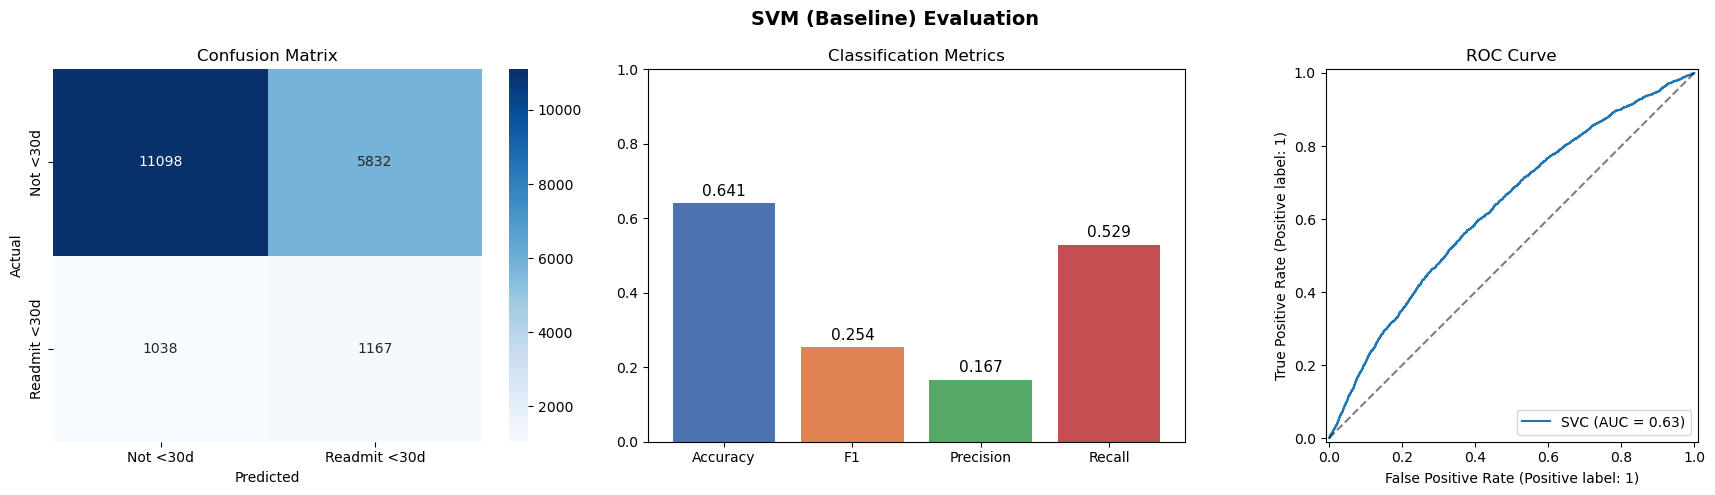

In [15]:
def plot_evaluation(y_true, y_pred, model, X_test, title, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Not <30d', 'Readmit <30d'],
                yticklabels=['Not <30d', 'Readmit <30d'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix')

    # Metrics bar chart
    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
    }
    bars = axes[1].bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Classification Metrics')
    for bar, val in zip(bars, metrics.values()):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=11)

    # ROC curve
    RocCurveDisplay.from_estimator(model, X_test, y_true, ax=axes[2])
    axes[2].set_title('ROC Curve')
    axes[2].plot([0,1], [0,1], 'k--', alpha=0.5)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')

    plt.show()
    return metrics

baseline_metrics = plot_evaluation(
    y_test, y_pred_base, svm_baseline, X_test_sc,
    'SVM (Baseline) Evaluation',
    save_path=RESULTS_DIR / 'svm_baseline_eval.png'
)

## 4. Hyperparameter Tuning with GridSearchCV

We tune `C` (regularization strength) and `gamma` (RBF kernel width) using 3-fold
stratified cross-validation, optimizing for F1 score on the minority class.

In [16]:
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(
        kernel='rbf',
        class_weight='balanced' if use_balanced else None,
        random_state=42,
        probability=True
    ),
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_sub, y_sub)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV F1:  {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'C': 1, 'gamma': 0.01}
Best CV F1:  0.2620


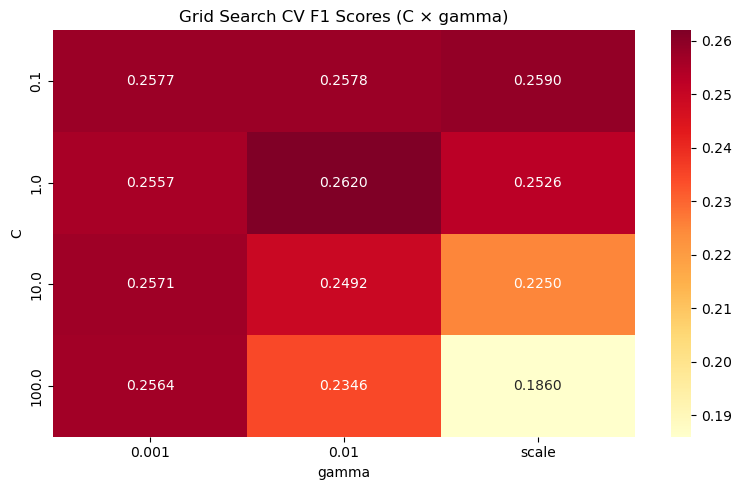

Saved → /Users/sraghvianchaliya/DS4400FinalProject/results/svm_gridsearch_heatmap.png


In [17]:
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Grid Search CV F1 Scores (C × gamma)')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR / "svm_gridsearch_heatmap.png"}')

## 5. Tuned SVM — Evaluation on Test Set

In [18]:
svm_tuned = grid_search.best_estimator_
y_pred_tuned = svm_tuned.predict(X_test_sc)

print(f'=== Tuned SVM (C={svm_tuned.C}, gamma={svm_tuned.gamma}) ===')
print(f'class_weight: {"balanced" if use_balanced else "None (SMOTE used)"}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Not <30d', 'Readmit <30d']))

=== Tuned SVM (C=1, gamma=0.01) ===
class_weight: balanced

              precision    recall  f1-score   support

    Not <30d       0.92      0.68      0.78     16930
Readmit <30d       0.18      0.52      0.26      2205

    accuracy                           0.66     19135
   macro avg       0.55      0.60      0.52     19135
weighted avg       0.83      0.66      0.72     19135



Saved → /Users/sraghvianchaliya/DS4400FinalProject/results/svm_tuned_eval.png


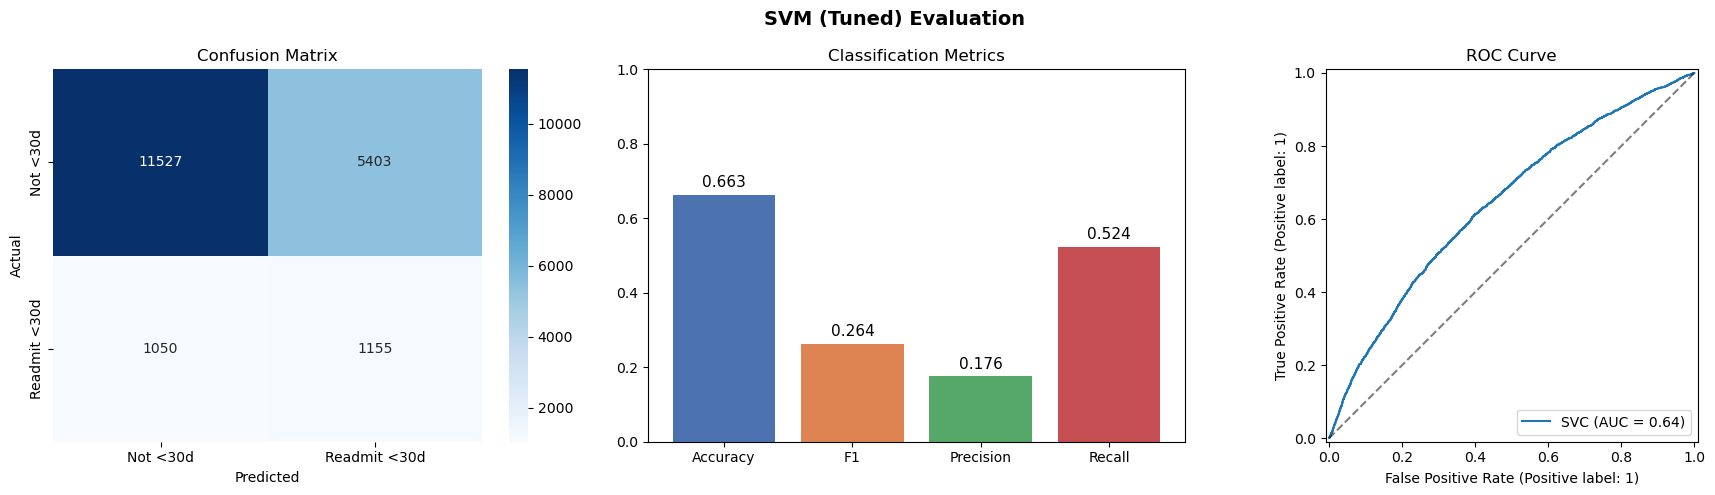

In [19]:
tuned_metrics = plot_evaluation(
    y_test, y_pred_tuned, svm_tuned, X_test_sc,
    'SVM (Tuned) Evaluation',
    save_path=RESULTS_DIR / 'svm_tuned_eval.png'
)

## 6. Cross-Validation F1 Scores

5-Fold CV F1 scores: [0.27024009 0.2629006  0.23766816 0.26151222 0.26421224]
Mean: 0.2593 ± 0.0112


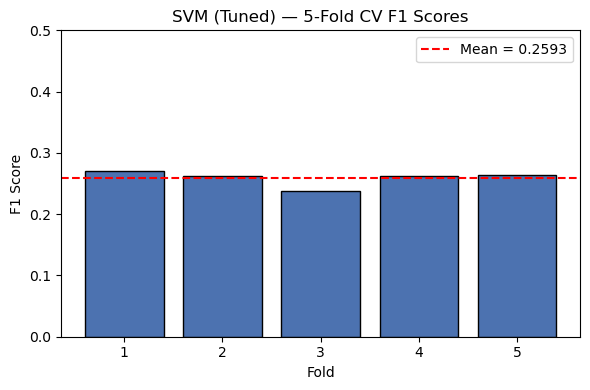

Saved → /Users/sraghvianchaliya/DS4400FinalProject/results/svm_cv_f1_scores.png


In [21]:
results_df = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_
n_splits = grid_search.cv.get_n_splits()
cv_f1 = np.array([results_df.loc[best_idx, f'split{i}_test_score'] for i in range(n_splits)])

print(f'{n_splits}-Fold CV F1 scores (best params from GridSearch): {cv_f1}')
print(f'Mean: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, n_splits + 1), cv_f1, color='#4C72B0', edgecolor='black')
plt.axhline(cv_f1.mean(), color='red', linestyle='--', label=f'Mean = {cv_f1.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('SVM (Tuned) — Cross-Validation F1 Scores')
plt.ylim(0, max(cv_f1.max() * 1.3, 0.5))
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_cv_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR / "svm_cv_f1_scores.png"}')

## 7. Baseline vs Tuned Comparison

In [ ]:
comparison = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Tuned': tuned_metrics
}).T

print(comparison.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(8, 5))
comparison.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('SVM: Baseline vs Tuned')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR / "svm_baseline_vs_tuned.png"}')

## 8. Save Model & Results

In [ ]:
joblib.dump(svm_tuned, RESULTS_DIR / 'svm_tuned_model.pkl')

results_summary = pd.DataFrame({
    'Model': ['SVM_Baseline', 'SVM_Tuned'],
    'Accuracy':  [baseline_metrics['Accuracy'],  tuned_metrics['Accuracy']],
    'F1':        [baseline_metrics['F1'],         tuned_metrics['F1']],
    'Precision': [baseline_metrics['Precision'],  tuned_metrics['Precision']],
    'Recall':    [baseline_metrics['Recall'],     tuned_metrics['Recall']],
    'C':         [1.0,                            svm_tuned.C],
    'gamma':     ['scale',                        svm_tuned.gamma],
})
results_summary.to_csv(RESULTS_DIR / 'svm_results.csv', index=False)

print('Saved:')
print(f'  Model  → {RESULTS_DIR / "svm_tuned_model.pkl"}')
print(f'  Results → {RESULTS_DIR / "svm_results.csv"}')
print()
print(results_summary.to_string(index=False))